# Yapay Sinir Ağları Dersi - Uçak Bileti Fiyat Tahmini (Regresyon) Ödevi

Bu çalışmada amaç, uçak bileti özelliklerini kullanarak bilet fiyatlarını tahmin etmektir. Hedef değişkenimiz sürekli bir sayısal değer (Price_USD) olduğu için problem tipi **Regresyon** olarak belirlenmiştir.

## Adım 1: Veri Setinin Yüklenmesi
Kaggle üzerinden uçak bileti veri setini ortama indiriyor ve makine öğrenmesi süreçlerinde kullanabilmek adına Pandas kütüphanesi ile tablo (DataFrame) formatına dönüştürüyoruz.

In [ ]:
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("syedaeman2212/airline-ticket-prices-dataset")

print("Path to dataset files:", path)
import os
import pandas as pd

# İndirilen dosyanın tam yolunu bulalım
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

# Veriyi bir "DataFrame" (tablo) olarak yükleyelim
df = pd.read_csv(full_path)

df.head(20)


Using Colab cache for faster access to the 'airline-ticket-prices-dataset' dataset.
Path to dataset files: /kaggle/input/airline-ticket-prices-dataset


,Ticket_ID,Airline,Origin,Destination,Distance_km,Class,Days_Before_Departure,Price_USD
0,1,Saudia,Mumbai,Paris,2643,Economy,28,555.30
1,2,Etihad,Istanbul,Jeddah,8266,Business,98,2070.27
2,3,British Airways,Dubai,Riyadh,2698,First,21,1883.11
3,4,Emirates,London,Istanbul,7956,First,24,5349.65
4,5,Qatar Airways,Doha,Dubai,1308,Business,60,516.19
5,6,Turkish Airlines,Mumbai,Istanbul,9382,First,19,6495.84
6,7,Emirates,Doha,Dubai,3506,Economy,85,439.16
7,8,Turkish Airlines,Istanbul,Doha,6122,First,88,2323.31
8,9,Qatar Airways,Paris,Riyadh,7150,Business,24,3032.38
9,10,Flynas,New York,Jeddah,3760,First,36,2282.17


## Adım 2: Veri Setinin Yapısal Analizi (Keşifsel Veri Analizi)
Modele geçmeden önce veri setinin boyutunu, içerdiği veri tiplerini ve eksik değer (NaN) olup olmadığını kontrol ediyoruz. Yapay sinir ağları veri tiplerine karşı hassastır; eksik veya metin tabanlı veriler eğitim sırasında hata üretir.

In [ ]:
# Veri setinde kaç satır ve sütun var?
print("Veri seti boyutu:", df.shape)

# Sütunların veri tipleri neler? (Sayı mı, metin mi?)
print(df.dtypes)

# Hiç boş hücre var mı?
print(df.isnull().sum())

Veri seti boyutu: (250, 8)
Ticket_ID                  int64
Airline                   object
Origin                    object
Destination               object
Distance_km                int64
Class                     object
Days_Before_Departure      int64
Price_USD                float64
dtype: object
Ticket_ID                0
Airline                  0
Origin                   0
Destination              0
Distance_km              0
Class                    0
Days_Before_Departure    0
Price_USD                0
dtype: int64


## Adım 3: Veri Ön İşleme (Preprocessing)
Modelin tahmin yeteneğini saptırmaması için `Ticket_ID` gibi fiyata hiçbir etkisi olmayan sütunları veri setinden çıkarıyoruz.

Ayrıca "Havayolu", "Kalkış", "Varış" ve "Sınıf" gibi kategorik (metin) verileri, sinir ağının anlayabileceği matematiksel tensörlere dönüştürmek için **One-Hot Encoding** yöntemiyle sayısallaştırıyoruz. Son olarak veriyi Girdi Özellikleri (X) ve Hedef Değişken (y) olarak ikiye ayırıyoruz.

In [ ]:
# Eğer Ticket_ID varsa sil, yoksa görmezden gel
if 'Ticket_ID' in df.columns:
    df = df.drop(columns=['Ticket_ID'])

# 2. Metin (Kategorik) verileri sayıya çevirelim
# Bu işleme 'One-Hot Encoding' denir.
df_final = pd.get_dummies(df, columns=['Airline', 'Origin', 'Destination', 'Class'])

# 3. Girdi (X) ve Hedef (y) ayrımı yapalım
# Amacımız Price_USD değerini tahmin etmek
X = df_final.drop(columns=['Price_USD'])
y = df_final['Price_USD']

print("Yeni tablo sütun sayısı:", X.shape[1])
df_final.head()

Yeni tablo sütun sayısı: 33


,Distance_km,Days_Before_Departure,Price_USD,Airline_British Airways,Airline_Emirates,Airline_Etihad,Airline_Flynas,Airline_Lufthansa,Airline_Qatar Airways,Airline_Saudia,...,Destination_Istanbul,Destination_Jeddah,Destination_London,Destination_Mumbai,Destination_New York,Destination_Paris,Destination_Riyadh,Class_Business,Class_Economy,Class_First
0,2643,28,555.30,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,True,False
1,8266,98,2070.27,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
2,2698,21,1883.11,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,7956,24,5349.65,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
4,1308,60,516.19,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


### Eğitim/Test Bölünmesi ve Ölçekleme
Modelin ezberlemesini önlemek ve genelleme başarısını ölçebilmek için veri kümesini **%70 Eğitim, %15 Doğrulama ve %15 Test** olarak üç parçaya ayırıyoruz.

Yapay sinir ağları (MLP) "gradient descent" optimizasyonu ile çalıştığı için, giriş özelliklerinin ölçekleri birbirine benzer olmalıdır. Farklı ölçekler öğrenmeyi yavaşlatır ve modeli kararsız hale getirir. Bu yüzden `StandardScaler` kullanarak verileri standardize ediyoruz. Veri sızıntısını (data leakage) engellemek adına, ölçekleyici (scaler) sadece eğitim setinden öğrenilecek şekilde (fit) ayarlanmıştır.

In [ ]:
 from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Veriyi bölme
# %70 Eğitim, %30 Geçici (Test+Val)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Geçici kısmı Test ve Validation olarak ikiye bölme (%15 + %15)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# 2. Ölçekleme (YSA için kritik adım)
scaler = StandardScaler()
# Scaler sadece train verisinden öğrenir (fit)
X_train_scaled = scaler.fit_transform(X_train)
# Val ve test sadece dönüştürülür (transform)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Veriler başarıyla bölündü ve ölçeklendi!")

Veriler başarıyla bölündü ve ölçeklendi!


## Adım 4: Yapay Sinir Ağı (MLP) Modelinin Kurulması ve Eğitilmesi
Model mimarisi, giriş ve çıkış katmanları arasına yerleştirilmiş 2 gizli katmanlı (64 ve 32 nöronlu) bir Çok Katmanlı Algılayıcı (MLP) olarak tasarlanmıştır.

* **Aktivasyon:** Gizli katmanlarda, ağın karmaşık ve doğrusal olmayan ilişkileri öğrenebilmesi için `relu` fonksiyonu kullanılmıştır.
* **Çıkış Katmanı:** Sürekli bir tahmin (fiyat) yapıldığı için çıkışta 1 nöron ve `linear` aktivasyon fonksiyonu tercih edilmiştir.
* **Optimizasyon:** Kayıp (loss) fonksiyonu olarak Ortalama Karesel Hata (MSE), optimizasyon algoritması olarak ise 'adam' kullanılmıştır.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Model Mimarisi Oluşturma (Architecture)
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)), # Giriş katmanı
    layers.Dense(64, activation='relu'),            # 1. Gizli katman
    layers.Dense(32, activation='relu'),            # 2. Gizli katman
    layers.Dense(1, activation='linear')            # Çıkış katmanı (Regresyon için 1 nöron)
])

# 2. Modeli Derleme (Optimization)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 3. Modeli Eğitme (Training)
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,      # Veriyi kaç kere baştan sona okuyacak?
    batch_size=10,   # Her adımda kaç örnek kullanacak?
    verbose=1        # Eğitim sürecini ekranda göster
)

print("\nModel eğitimi tamamlandı!")

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 7601855.0000 - mae: 2120.2905 - val_loss: 9247291.0000 - val_mae: 2191.5020
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7616379.5000 - mae: 2146.4270 - val_loss: 9240574.0000 - val_mae: 2189.9250
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7391635.0000 - mae: 2057.5508 - val_loss: 9230248.0000 - val_mae: 2187.6101
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5553530.0000 - mae: 1846.9573 - val_loss: 9214698.0000 - val_mae: 2184.2537
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6644606.0000 - mae: 2015.4467 - val_loss: 9192172.0000 - val_mae: 2179.5259
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7029215.0000 - mae: 2000.9559 - val_loss: 9159408.0000 - val_mae: 2172.9590
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6706625.5000 - mae: 1952.2083 - val_loss: 9117891.0000 - val_mae: 2164.7910
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - l

## Adım 5: Model Performansının Değerlendirilmesi
Modelin her bir eğitim adımında (epoch) yaptığı hataları görselleştiriyoruz. Eğitim (Train) ve Doğrulama (Val) hata çizgilerinin birlikte aşağı yönlü bir eğilim göstermesi, modelin aşırı öğrenmeye (overfitting) düşmeden başarılı bir şekilde öğrendiğinin göstergesidir.

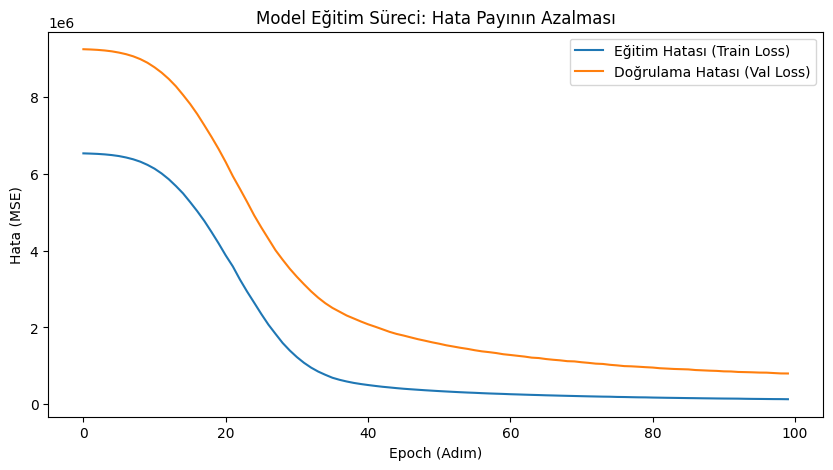

In [ ]:
import matplotlib.pyplot as plt

# 1. Eğitim ve Doğrulama Kayıplarını (Loss) Çizdirelim
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Eğitim Hatası (Train Loss)')
plt.plot(history.history['val_loss'], label='Doğrulama Hatası (Val Loss)')
plt.title('Model Eğitim Süreci: Hata Payının Azalması')
plt.xlabel('Epoch (Adım)')
plt.ylabel('Hata (MSE)')
plt.legend()
plt.show()

### Sayısal Performans Metrikleri
Modelin tahmin gücünü regresyon problemlerinde yaygın olarak kullanılan metriklerle ölçüyoruz:
* **R-Kare (R2):** Modelin, bilet fiyatlarındaki değişkenliğin ne kadarını başarıyla açıkladığını gösterir.
* **MAE ve RMSE:** Modelin tahminlerinde bilet fiyatı (USD) cinsinden ortalama ne kadar saptığını ifade eder.
* **MAPE (%):** Modelin oransal olarak (yüzde kaç) hata yaptığını gösterir.

In [ ]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1) Metrik hesaplama fonksiyonu
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    # MAPE (Yüzdesel Hata)
    eps = 1e-8
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

    r2 = r2_score(y_true, y_pred)
    return {"R2": r2, "MSE": mse, "RMSE": rmse, "MAE": mae, "MAPE(%)": mape}

# 2) Tahminlerin yapılması
y_pred_train = model.predict(X_train_scaled).reshape(-1)
y_pred_val   = model.predict(X_val_scaled).reshape(-1)
y_pred_test  = model.predict(X_test_scaled).reshape(-1)

# 3) Metriklerin hesaplanması
metrics_train = compute_metrics(y_train, y_pred_train)
metrics_val   = compute_metrics(y_val, y_pred_val)
metrics_test  = compute_metrics(y_test, y_pred_test)

# 4) Sonuçları Tablo Olarak Göster
metrics_df = pd.DataFrame([
    {"Bölüm (Split)": "Eğitim (Train)", **metrics_train},
    {"Bölüm (Split)": "Doğrulama (Val)", **metrics_val},
    {"Bölüm (Split)": "Test", **metrics_test},
])

display(metrics_df)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


,Bölüm (Split),R2,MSE,RMSE,MAE,MAPE(%)
0,Eğitim (Train),0.951044,127503.390064,357.076168,253.930648,22.053308
1,Doğrulama (Val),0.819991,800001.251834,894.427891,550.229996,33.612809
2,Test,0.889918,222612.329600,471.818111,362.648254,29.409997


## Adım 6: Hata Analizi (Residuals) ve Final Görselleştirmesi
Son aşamada, modelin tahmin performansını görsel olarak test ediyoruz.
* **Gerçek vs Tahmin Grafiği:** Mavi noktalar $y=x$ referans çizgisine ne kadar yakın kümeleniyorsa, model o kadar isabetli tahmin yapıyor demektir.
* **Residual (Hata) Grafiği:** İdeal bir modelde hataların (gerçek ile tahmin arasındaki farkın) $0$ referans çizgisi etrafında belirli bir desen oluşturmadan rastgele saçılması beklenir.

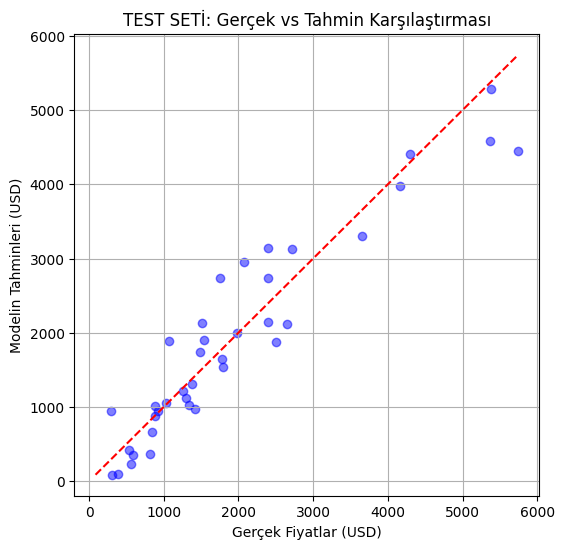

In [ ]:
import matplotlib.pyplot as plt

def plot_final_results(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    # Noktaları çiz (Scatter)
    plt.scatter(y_true, y_pred, alpha=0.5, color='blue')

    # Mükemmel tahmin çizgisini ekle (y=x)
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

    plt.title(title)
    plt.xlabel("Gerçek Fiyatlar (USD)")
    plt.ylabel("Modelin Tahminleri (USD)")
    plt.grid(True)
    plt.show()

# Test verisi için final görsellendirmesi
plot_final_results(y_test, y_pred_test, "TEST SETİ: Gerçek vs Tahmin Karşılaştırması")

### Hedef Dağılımı ve Özellik İlişkileri
Regresyon algoritmalarında hedef değişkenin (fiyat) dağılımı, modelin öğrenme performansını doğrudan etkiler. Fiyat dağılımını görmek için Histogram; sayısal özelliklerin birbiriyle ve hedefle olan ilişkisini incelemek için ise Korelasyon Matrisi oluşturulmuştur. Bu sayede "Hangi sayısal özellik bilet fiyatında daha etkilidir?" sorusu görselleştirilmiştir.

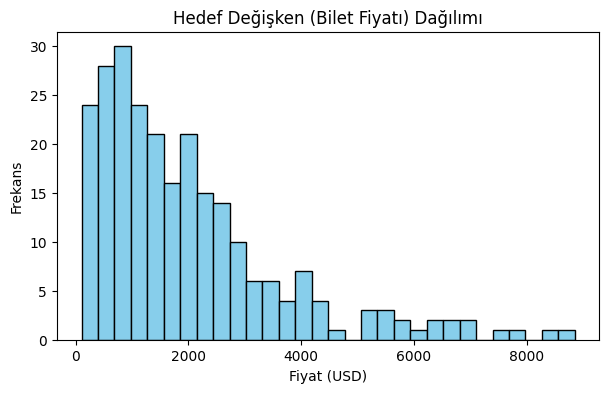

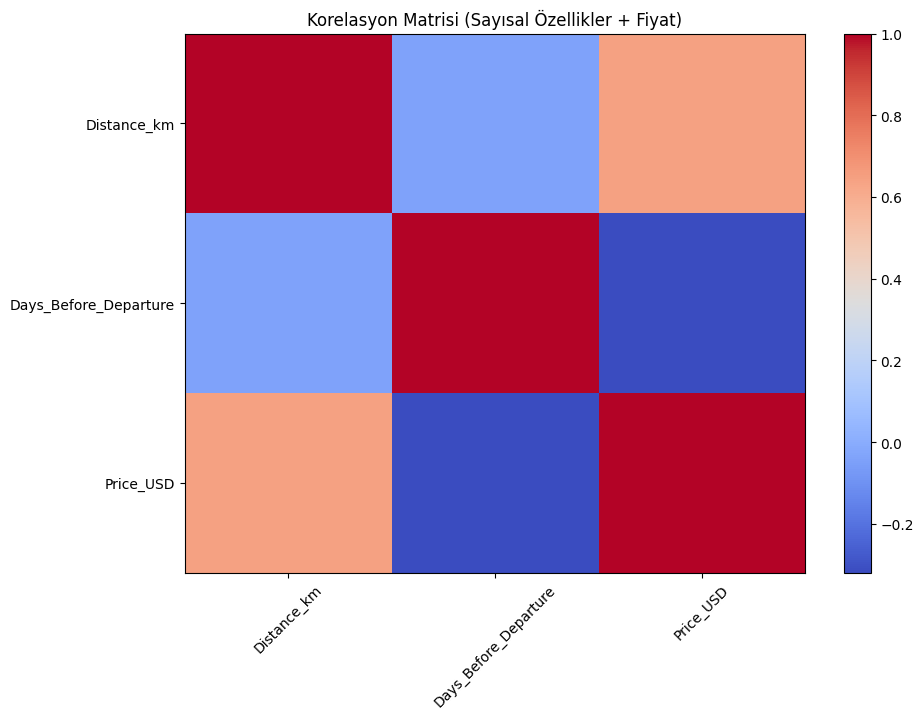

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Hedef Değişken (Price_USD) Dağılımı
plt.figure(figsize=(7,4))
plt.hist(df["Price_USD"], bins=30, color='skyblue', edgecolor='black')
plt.title("Hedef Değişken (Bilet Fiyatı) Dağılımı")
plt.xlabel("Fiyat (USD)")
plt.ylabel("Frekans")
plt.show()

# 2. Korelasyon Matrisi
# Sadece sayısal sütunlar arasındaki ilişkiyi görürüz
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,7))
plt.imshow(corr, aspect='auto', cmap='coolwarm')
plt.colorbar()
plt.title("Korelasyon Matrisi (Sayısal Özellikler + Fiyat)")
plt.xticks(ticks=np.arange(len(corr.columns)), labels=corr.columns, rotation=45)
plt.yticks(ticks=np.arange(len(corr.columns)), labels=corr.columns)
plt.show()

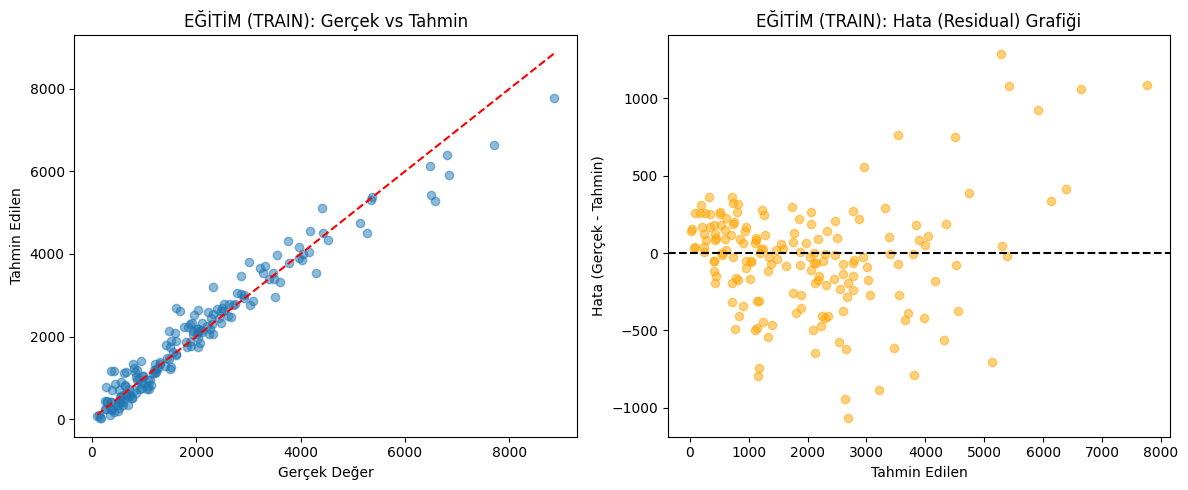

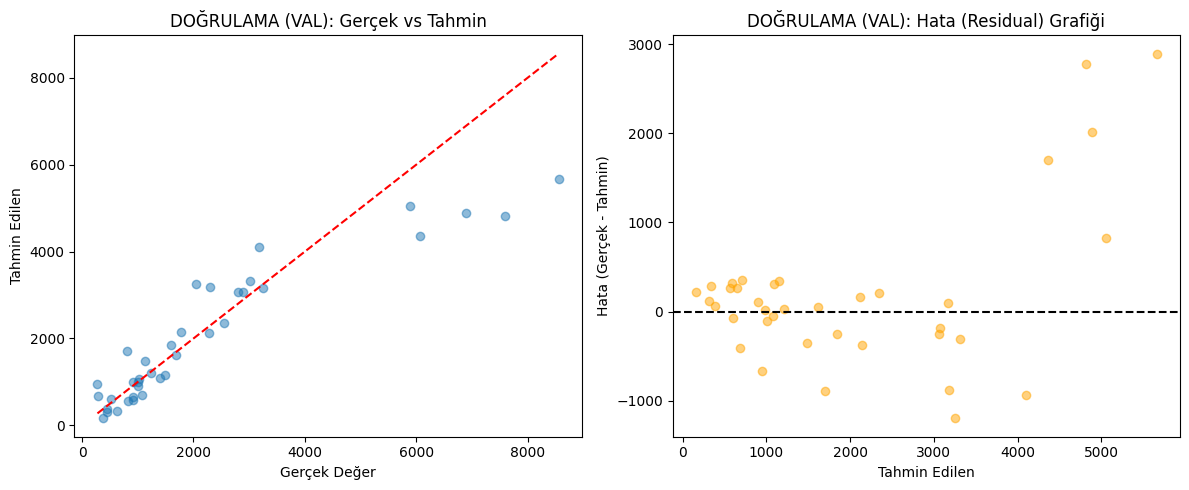

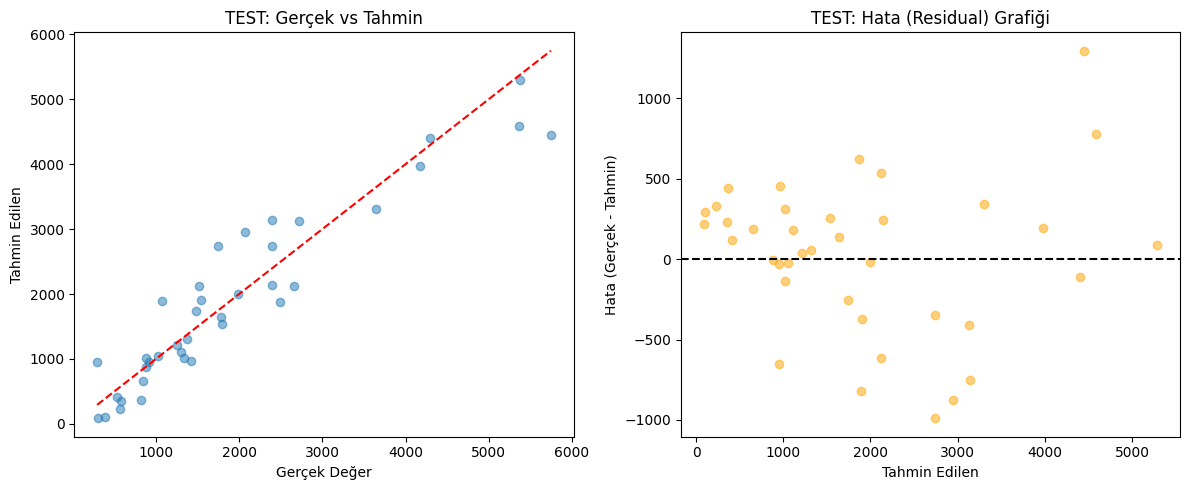

In [ ]:
def plot_results_full(y_true, y_pred, title):
    # Gerçek vs Tahmin Grafiği
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.title(f"{title}: Gerçek vs Tahmin")
    plt.xlabel("Gerçek Değer")
    plt.ylabel("Tahmin Edilen")

    # Residual (Hata) Grafiği
    plt.subplot(1, 2, 2)
    residuals = y_true - y_pred
    plt.scatter(y_pred, residuals, alpha=0.5, color='orange')
    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"{title}: Hata (Residual) Grafiği")
    plt.xlabel("Tahmin Edilen")
    plt.ylabel("Hata (Gerçek - Tahmin)")

    plt.tight_layout()
    plt.show()

# Tüm setler için grafiklerin çizilmesi
plot_results_full(y_train, y_pred_train, "EĞİTİM (TRAIN)")
plot_results_full(y_val, y_pred_val, "DOĞRULAMA (VAL)")
plot_results_full(y_test, y_pred_test, "TEST")